In [ ]:
import gensim.models
from corus import load_lenta
import spacy
import string
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

--2026-03-01 18:04:48--  https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/87156914/0b363e00-0126-11e9-9e3c-e8c235463bd6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-01T19%3A00%3A56Z&rscd=attachment%3B+filename%3Dlenta-ru-news.csv.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-01T18%3A00%3A19Z&ske=2026-03-01T19%3A00%3A56Z&sks=b&skv=2018-11-09&sig=GyfqQVSE5eyjnTQ5ON1kBxyDbFvipA9bpSZlzFFfV0U%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MjM5MTg4OCwibmJmIjoxNzcyMzg4Mjg4LCJwYXRoIjoicmVsZWFzZWFzc2V0cH

# 1. Загрузите набор данных lenta-ru-news с помощью библиотеки Corus для задачи классификации текстов по топикам

In [ ]:
path = 'lenta-ru-news.csv.gz'
records = load_lenta(path)

# 2. Подготовка данных к обучению

## 2.1 Выделим репрезентативную часть датасета размерм 100_000 текстов

Т.к классы по топикам несбалансированы, то было решено из всего набора данных оставить топики больше 4000 записей и ограничить также количество топиков сверху 10000 записями, таким образом были сформированы классы(топики) с общим размером 100_000 текстов и без сильного дисбаланса классов

In [ ]:
def get_representative(records, target_size, min_class_size=4000, max_class_size=10000, random_state=42):
    """ Получение репрезентативной выборки из records"""
    all_data = []
    for i, record in enumerate(records):
        if hasattr(record, 'topic') and record.topic:
            all_data.append({
                'title': record.title,
                'text': record.text,
                'topic': record.topic
            })

        if i % 100000 == 0:
            print(f"Загружено {len(all_data)} записей")

    print("\n")

    df_all = pd.DataFrame(all_data)
    print(f"Всего загружено: {len(df_all)} записей")
    print(f"Уникальных топиков: {df_all['topic'].nunique()}")
    print("\n")
    topic_raspr = df_all['topic'].value_counts()
    print(f"Распределение топиков:")
    print(topic_raspr)
    print("\n")
    topics = topic_raspr[topic_raspr >= min_class_size].index.tolist()
    print(f"Топиков с размером >= {min_class_size} ==  {len(topics)}")


    df_filtered = df_all[df_all['topic'].isin(topics)].copy()

    dfs_balanced = []

    for topic in topics:
        topic_data = df_filtered[df_filtered['topic'] == topic]

        if len(topic_data) > max_class_size:
            topic_razd = topic_data.sample(n=max_class_size, random_state=random_state)
        else:
            topic_razd = topic_data

        dfs_balanced.append(topic_razd)
        print(f"  {topic}: {len(topic_data)} теперь стало {len(topic_razd)}")

    df_balanced = pd.concat(dfs_balanced, ignore_index=True)


    if len(df_balanced) > target_size:
        df_sample, _ = train_test_split(df_balanced,train_size=target_size,
            stratify=df_balanced['topic'],random_state=random_state)
    else:
        df_sample = df_balanced

    print('\n')
    print(f"Итоговая выборка:")
    print(f"Всего записей теперь: {len(df_sample)}")
    print(f"Уникальных топиков: {df_sample['topic'].nunique()}")
    print('\n')
    print(f"Распределение теперь:")
    print(df_sample['topic'].value_counts())

    return df_sample


df = get_representative(records, target_size=100000, min_class_size=4000,max_class_size=10000)

Загружено 1 записей
Загружено 99984 записей
Загружено 199968 записей
Загружено 299914 записей
Загружено 399900 записей
Загружено 499862 записей
Загружено 599820 записей
Загружено 699798 записей


Всего загружено: 739148 записей
Уникальных топиков: 23


Распределение топиков:
topic
Россия               160519
Мир                  136680
Экономика             79538
Спорт                 64421
Культура              53803
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44675
Из жизни              27611
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64


Топиков с размером >= 4000 ==  14
  Россия: 16

In [ ]:
df.head(5)

,title,text,topic
16984,Столица Таджикистана осталась без света,Столица Таджикистана Душанбе практически полно...,Мир
3131,Мотопарад в Москве установил рекорд,Более пяти тысяч человек приняли участие в мот...,Россия
107944,КНДР провела неудачный запуск ракеты в день ро...,Северная Корея попыталась запустить баллистиче...,Силовые структуры
117982,Путин поручил рассмотреть вопрос о введении ут...,Президент России Владимир Путин поручил правит...,Бизнес
120570,Поляки отправили в Россию последнюю партию отр...,Последняя партия ядерных отходов из польского ...,Бизнес


In [ ]:
df['topic'].value_counts()

,count
topic,
Мир,7601
Спорт,7601
Бывший СССР,7601
Дом,7600
Силовые структуры,7600
Россия,7600
Интернет и СМИ,7600
Наука и техника,7600
Культура,7600


## 2.2 Предобработайте данные: реализуйте оптимальную, на ваш взгляд, предобработку текстов (нормализация, очистка, стемминг/лемматизация и т.п.) и таргета. Постарайтесь добиться приемлемой скорости обработки за счет оптимизаций.

In [ ]:
nlp = spacy.load('ru_core_news_lg', disable=["tagger", "parser", "ner"])

In [ ]:
df['full_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
texts_lower = df['full_text'].str.lower().tolist()

In [ ]:
df.iloc[1]

,3131
title,Мотопарад в Москве установил рекорд
text,Более пяти тысяч человек приняли участие в мот...
topic,Россия
full_text,Мотопарад в Москве установил рекорд Более пяти...


In [ ]:
texts_lower[1]

'мотопарад в\xa0москве установил рекорд более пяти тысяч человек приняли участие в мотопараде по случаю второго московского мотофестиваля. об этом сообщили тасс в пресс-службе департамента транспорта и развития дорожно-транспортной инфраструктуры москвы в субботу, 5 мая. там отметили, что парад собрал рекордное количество участников. «событие прошло спокойно, без дтп и происшествий», — добавили в ведомстве. мотоколонна проехала от проспекта академика сахарова по проспекту мира, остановились на площади у памятника «рабочий и колхозница» и финишировали на смотровой площадке на воробьевых горах. еще одна площадка была организована в парке сокольники. глава департамента транспорта столицы максим ликсутов добавил, что москва занимает одно из первых мест в мире по динамике развития мотодвижения. «в прошлом году количество зарегистрированных мотоциклов в москве по сравнению с 2014 годом выросло почти на 40 процентов. мы поддерживаем популяризацию мототранспорта», — отметил он. '

In [ ]:
processed_texts = []
for doc in nlp.pipe(texts_lower, batch_size=500):
    tokens = [token.lemma_ for token in doc if token.lemma_ not in string.punctuation and not token.is_stop]
    processed_texts.append(' '.join(tokens))

df['token_text'] = processed_texts


Сохраним набор данных, чтобы после перезапуска не запускать предобработку снова

In [ ]:
df.to_csv('/content/drive/MyDrive/lenta_ru_news_lemma_csv', index=False)


In [6]:
df = pd.read_csv('/content/drive/MyDrive/lenta_ru_news_lemma_csv')


In [7]:
df.head(5)

,title,text,topic,full_text,token_text
0,Столица Таджикистана осталась без света,Столица Таджикистана Душанбе практически полно...,Мир,Столица Таджикистана осталась без света Столиц...,столица таджикистан остаться свет столица тадж...
1,Мотопарад в Москве установил рекорд,Более пяти тысяч человек приняли участие в мот...,Россия,Мотопарад в Москве установил рекорд Более пяти...,мотопарад москва установить рекорд пять тыся...
2,КНДР провела неудачный запуск ракеты в день ро...,Северная Корея попыталась запустить баллистиче...,Силовые структуры,КНДР провела неудачный запуск ракеты в день ро...,кндр провести неудачный запуск ракета день р...
3,Путин поручил рассмотреть вопрос о введении ут...,Президент России Владимир Путин поручил правит...,Бизнес,Путин поручил рассмотреть вопрос о введении ут...,путин поручить рассмотреть вопрос введение у...
4,Поляки отправили в Россию последнюю партию отр...,Последняя партия ядерных отходов из польского ...,Бизнес,Поляки отправили в Россию последнюю партию отр...,поляк отправить россия последний партия отра...


In [8]:
df.shape

(100000, 5)

## 2.3 Кратко описание пайплайна предобработки, на котором остановился, и почему.


Этот пайплайн предобработки текста включает следующие этапы:

Объединение: объединили заголовок и основной текст новости в одно текстовое поле full_text, чтобы анализировать полный текст новости.

Приведение к нижнему регистру всех слов и проводим лемматизацию для уменьшения размерности признакового пространства, чтобы в дальнейшем вектор одного и того же слова из-за регистров не считался за разное кол-во слов

Лемматизация(приведение к нормальной форме слова) хоть и работает дольше стемминга, но проводит более качественную обработку, сохраняя смысловую связность слов, а не просто обрезает окончания, также были исключены различные стоп-слова т.к не несут в себе большой смысловой нагрузки и текст очищен от знаков препинания

Таким образом токенизация на основе слов была проведена следующим образом и данный набор операций составляет пригодный формат (в столбце token_text) для дальнейшего уже векторного представления этих слов

## 2.4 Разделим датасет на обучающую, валидационную и тестовую выборки со стратификацией в пропорции 60/20/20. В качестве целевой переменной используем атрибут topic

In [ ]:
# Разделение на train (60%) и остальное (40%)
X_train, X_razd, y_train, y_razd = train_test_split(df['token_text'], df['topic'],test_size=0.4,stratify=df['topic'],random_state=42)

# Разделение остального на val (20%) и test (20%)
X_val, X_test, y_val, y_test = train_test_split(X_razd,y_razd,test_size=0.5, stratify=y_razd,random_state=42)

# 3. Замерим базовое качество с любым dummy-бейзлайном

In [10]:
dummy = DummyClassifier(random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

print(classification_report(y_val, y_pred_dummy))

                   precision    recall  f1-score   support

           Бизнес       0.00      0.00      0.00      1125
      Бывший СССР       0.08      1.00      0.14      1520
              Дом       0.00      0.00      0.00      1520
         Из жизни       0.00      0.00      0.00      1520
   Интернет и СМИ       0.00      0.00      0.00      1520
         Культура       0.00      0.00      0.00      1520
              Мир       0.00      0.00      0.00      1520
  Наука и техника       0.00      0.00      0.00      1520
      Путешествия       0.00      0.00      0.00       974
           Россия       0.00      0.00      0.00      1520
Силовые структуры       0.00      0.00      0.00      1520
            Спорт       0.00      0.00      0.00      1520
         Ценности       0.00      0.00      0.00      1181
        Экономика       0.00      0.00      0.00      1520

         accuracy                           0.08     20000
        macro avg       0.01      0.07      0.01     2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


С dummy-бейзлайном по предсказанию самого частого класса получилась общая accuracy = 8%, модель работает не лучше случайного угадывания самого частого класса, т.к и настроена на это. Также и precision c recall показывают максимально низкие результаты.  



# 4 Обучим модель sklearn.linear_model.LogisticRegression с двумя вариантами векторизации

## 4.1 с sklearn.feature_extraction.text.CountVectorizer


In [11]:
model_CountVect = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', LogisticRegression(random_state=128, max_iter=1000))])

model_CountVect.fit(X_train, y_train)


Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=128))])

In [12]:
y_pred_CountVect = model_CountVect.predict(X_val)
print(classification_report(y_val, y_pred_CountVect))

                   precision    recall  f1-score   support

           Бизнес       0.81      0.78      0.79      1125
      Бывший СССР       0.86      0.86      0.86      1520
              Дом       0.91      0.89      0.90      1520
         Из жизни       0.72      0.73      0.72      1520
   Интернет и СМИ       0.78      0.77      0.77      1520
         Культура       0.87      0.88      0.88      1520
              Мир       0.72      0.72      0.72      1520
  Наука и техника       0.82      0.82      0.82      1520
      Путешествия       0.85      0.87      0.86       974
           Россия       0.65      0.68      0.67      1520
Силовые структуры       0.78      0.79      0.78      1520
            Спорт       0.96      0.95      0.96      1520
         Ценности       0.94      0.92      0.93      1181
        Экономика       0.80      0.79      0.80      1520

         accuracy                           0.82     20000
        macro avg       0.82      0.82      0.82     2

Т.к после всех обработок и прочего у нас нет сильного дисбаланса классов, macro и weighted avg близки друг к другу, видим, что качество в сравнении с dummy классификатором заметно выросло

## 4.2 с sklearn.feature_extraction.text.TfidfVectorizer

In [13]:
model_tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(random_state=128, max_iter=1000))])

model_tfidf.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=128))])

In [14]:
y_pred_tfidf = model_tfidf.predict(X_val)
print(classification_report(y_val, y_pred_tfidf))

                   precision    recall  f1-score   support

           Бизнес       0.82      0.77      0.79      1125
      Бывший СССР       0.87      0.89      0.88      1520
              Дом       0.91      0.89      0.90      1520
         Из жизни       0.72      0.76      0.74      1520
   Интернет и СМИ       0.79      0.79      0.79      1520
         Культура       0.86      0.89      0.87      1520
              Мир       0.74      0.75      0.75      1520
  Наука и техника       0.82      0.82      0.82      1520
      Путешествия       0.85      0.84      0.85       974
           Россия       0.70      0.68      0.69      1520
Силовые структуры       0.79      0.80      0.80      1520
            Спорт       0.96      0.95      0.95      1520
         Ценности       0.93      0.90      0.92      1181
        Экономика       0.82      0.80      0.81      1520

         accuracy                           0.82     20000
        macro avg       0.83      0.82      0.83     2

Лог.регрессия с tfidf векторизацией показала сравнительно похожие метрики, что и с CountVectorizer, нет явного лидера, хоть и tfidf превзошёл в macroavg на 1 процент

# 5. Попробуем улучшить качество, подобрав оптимальные гиперпараметры трансформаций и модели на кросс-валидации

Будем улучшать pipeline с tfidf векторизацией

In [20]:
pipeline_tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(random_state=128))
])

param_grid = {
    'vectorizer__max_features': [10000, None],
    'vectorizer__min_df': list(np.arange(1, 4)),
    'vectorizer__max_df': list(np.linspace(0.5, 1.0, 5)),
    'classifier__C': [0.1, 1,10],
    'classifier__max_iter': list(np.arange(1000, 1501, 100))
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=128)

rs = RandomizedSearchCV(
    pipeline_tfidf,
    param_grid,
    n_iter=20,
    cv=cv,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
    refit='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=128
)

rs.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=128, shuffle=True),
                   estimator=Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                                             ('classifier',
                                              LogisticRegression(random_state=128))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__C': [0.1, 1, 10],
                                        'classifier__max_iter': [np.int64(1000),
                                                                 np.int64(1100),
                                                                 np.int64(1200),
                                                                 np.int64(1300),
                                                                 np.int64(1400),
                                                                 np.int64(1500)],
                                        'vectorizer__max_df': [np.float64(0.5),
                                                               np.float64(0.625),
                                                               np.float64(0.75),
                                                               np.float64(0.875),
                                                               np.float64(1.0)],
                                        'vectorizer__max_features': [10000,
                                                                     None],
                                        'vectorizer__min_df': [np.int64(1),
                                                               np.int64(2),
                                                               np.int64(3)]},
                   random_state=128, refit='accuracy',
                   scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
                   verbose=1)

In [28]:
print("Лучшие параметры:", rs.best_params_)

Лучшие параметры: {'vectorizer__min_df': np.int64(3), 'vectorizer__max_features': None, 'vectorizer__max_df': np.float64(1.0), 'classifier__max_iter': np.int64(1200), 'classifier__C': 10}


In [25]:
best_model = rs.best_estimator_
y_pred_val = best_model.predict(X_val)

print("Метрики на валидационной выборке:")
print(classification_report(y_val, y_pred_val))


Метрики на валидационной выборке:
                   precision    recall  f1-score   support

           Бизнес       0.81      0.78      0.80      1125
      Бывший СССР       0.87      0.89      0.88      1520
              Дом       0.91      0.90      0.91      1520
         Из жизни       0.73      0.75      0.74      1520
   Интернет и СМИ       0.80      0.80      0.80      1520
         Культура       0.87      0.89      0.88      1520
              Мир       0.74      0.74      0.74      1520
  Наука и техника       0.82      0.83      0.83      1520
      Путешествия       0.86      0.86      0.86       974
           Россия       0.69      0.69      0.69      1520
Силовые структуры       0.81      0.81      0.81      1520
            Спорт       0.96      0.96      0.96      1520
         Ценности       0.94      0.92      0.93      1181
        Экономика       0.83      0.81      0.82      1520

         accuracy                           0.83     20000
        macro avg   

После подбора гиперпараметров удалось достичь лучшего качества модели, на одну сотую, на валидационной выборке

# 6.Оценим качество лучшего пайплайна на отложенной выборке, проведём анализ ошибок модели

In [26]:
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test)

print("Метрики на отложенной тестовой выборке:")
print(classification_report(y_test, y_pred_test))


Метрики на отложенной тестовой выборке:
                   precision    recall  f1-score   support

           Бизнес       0.79      0.78      0.79      1125
      Бывший СССР       0.87      0.87      0.87      1520
              Дом       0.92      0.91      0.91      1520
         Из жизни       0.72      0.77      0.75      1520
   Интернет и СМИ       0.80      0.78      0.79      1520
         Культура       0.87      0.89      0.88      1520
              Мир       0.73      0.75      0.74      1520
  Наука и техника       0.86      0.83      0.85      1520
      Путешествия       0.84      0.83      0.84       974
           Россия       0.70      0.68      0.69      1520
Силовые структуры       0.81      0.82      0.82      1520
            Спорт       0.96      0.96      0.96      1521
         Ценности       0.94      0.92      0.93      1180
        Экономика       0.81      0.79      0.80      1520

         accuracy                           0.83     20000
        macro 

Метрики на отложенной тестовой выборке также показывают неплохой результат, точность, macro, weighted avg в 83%

Проведём анализ ошибок

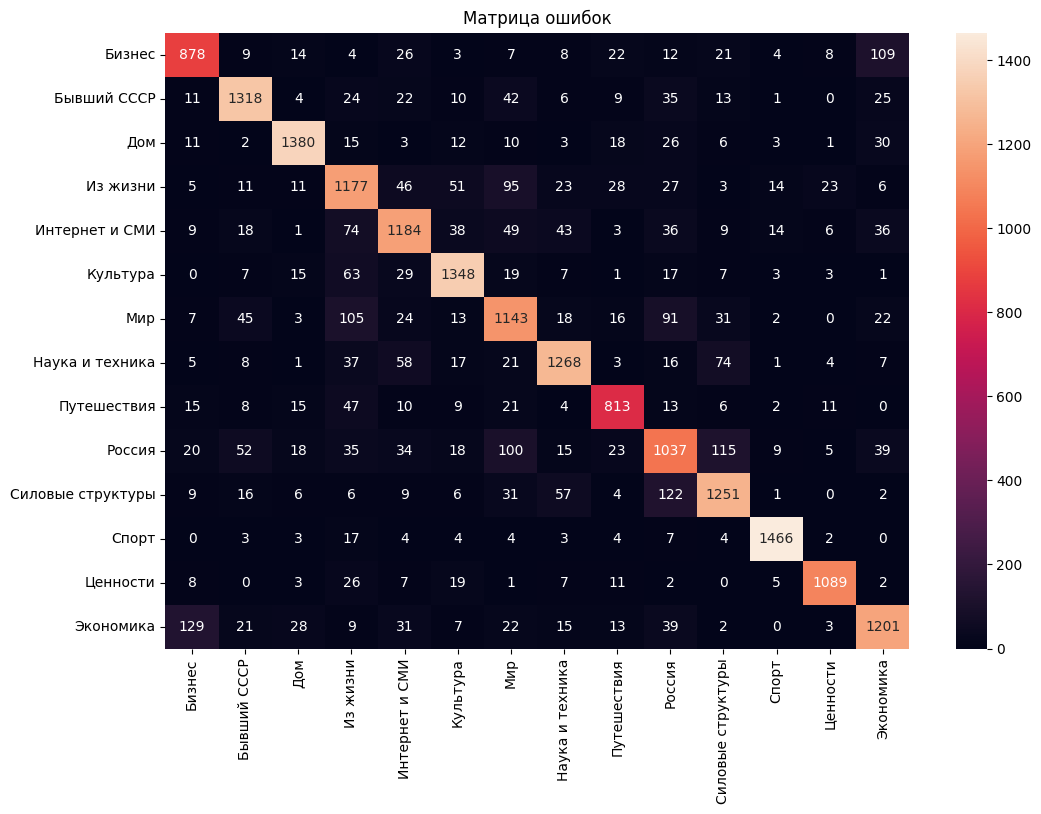

In [33]:
matr = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Матрица ошибок')
plt.show()


Видим, что наиболее частые ошибки в предсказаниях возникают у смежных тем, которые часто между собой пересекаются и семантически близки друг к другу.Например, такие темы как бизнес и экономика имеют больше всего ошибочных предсказаний, а также Мир и Россия... То есть темы, где в основном используются какие-то общие термины, имена собственные и так далее

# Выводы

Вывод, с помощью векторизации и модели логистической регрессии с подбором гиперпараметров удалось достичь неплохого качества на достаточно крупном датасете, видим, что большинство ошибок возникают на разделении некоторых тематик, которые в целом очень часто схожи друг с другом, где тексты и смысл часто пересекаются, содержат общие термины.
Для улучшения стоит обратиться к токенизации не просто отдельных слов, а возможно частей слов или n-gramm >=2, а также использовать информатиное векторное представление(эмбеддинги) для учёта контекста в текстах новостей, попробовать другие модели